# Selection criteria for the HMM hits

Working notebook for deciding when an hmmsearch hit counts as an ortholog of the arabinose cluster genes.

Input: the unfiltered hmmsearch `.tblout` files from `05_search_genomes.py` (no cutoff applied, hits go down to
HMMER's default E = 10), for both genome sets:
- `results/raw/Streptomycetae/`
- `results/raw/Actinobacteria/`

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/vol/local/calarass/Projects/ara_comp_genomics")
HMM_DIR = PROJECT_DIR / "hmm_search"
RAW_DIRS = {
    "Streptomycetae": HMM_DIR / "results" / "raw" / "Streptomycetae",
    "Actinobacteria": HMM_DIR / "results" / "raw" / "Actinobacteria",
}

# tblout columns (HMMER 3 --tblout); the last one, the description, can contain spaces
TBLOUT_COLS = [
    "target", "target_acc", "model", "model_acc",
    "evalue", "bitscore", "bias",
    "best_dom_evalue", "best_dom_bitscore", "best_dom_bias",
    "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
    "description",
]
FLOAT_COLS = ["evalue", "bitscore", "bias", "best_dom_evalue", "best_dom_bitscore", "best_dom_bias", "exp"]

## 1. Load the hits

In [4]:
def read_tblout(path):
    """Returns (hits table, finished): finished is False when the '# [ok]' line is missing."""
    rows = []
    finished = False
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                if line.startswith("# [ok]"):
                    finished = True
                continue
            rows.append(line.rstrip("\n").split(maxsplit=len(TBLOUT_COLS) - 1))
    return pd.DataFrame(rows, columns=TBLOUT_COLS), finished


tables = []
for genome_set, raw_dir in RAW_DIRS.items():
    for path in sorted(raw_dir.glob("*.tblout")):
        df, finished = read_tblout(path)
        if not finished:
            print("WARNING: search did not finish:", path.name)
        df["genome_set"] = genome_set
        df["tblout"] = path.stem
        tables.append(df)

hmm_hits = pd.concat(tables, ignore_index=True)
hmm_hits[FLOAT_COLS] = hmm_hits[FLOAT_COLS].astype(float)

# 'Genome|LOCUS_TAG|description|accession'; brackets dropped so '[Kitasatospora]_papulosa' matches RBH
hmm_hits["genome"] = hmm_hits.target.str.split("|").str[0].str.replace("[", "").str.replace("]", "")
hmm_hits["locus_tag"] = hmm_hits.target.str.split("|").str[1]
hmm_hits["gene"] = hmm_hits.model.str.extract(r"(SCO\d+)", expand=False)

# rank of each hit within its (genome, model): 1 = best-scoring protein
hmm_hits = hmm_hits.sort_values("bitscore", ascending=False)
hmm_hits["rank"] = hmm_hits.groupby(["genome_set", "genome", "model"]).cumcount() + 1

print(f"{len(hmm_hits)} hits from {hmm_hits.tblout.nunique()} genomes")
hmm_hits.groupby(["genome_set", "gene"]).agg(genomes=("genome", "nunique"), hits=("target", "size"))

23257 hits from 459 genomes


genomes  hits
genome_set     gene                  
Actinobacteria SCO2401      226   934
               SCO2402      248  3965
               SCO2407      189   270
               SCO2408      250  1563
               SCO2439      156   387
               SCO2440      232  1951
Streptomycetae SCO2401      197  1115
               SCO2402      207  6291
               SCO2407      199   455
               SCO2408      207  2247
               SCO2439      197   559
               SCO2440      207  3520

In [3]:
hmm_hits

,target,target_acc,model,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,...,dom,rep,inc,description,genome_set,tblout,genome,locus_tag,gene,rank
22675,Streptomyces_coelicolor_A3(2)|FQ762_RS12320|py...,-,Conserved-SCO2408,-,0.0,1273.0,32.9,0.000,1272.9,32.9,...,1,1,1,phosphate-dependent aminotransferase|WP_011028...,Actinobacteria,Streptomyces_coelicolor_A3(2),Streptomyces_coelicolor_A3(2),FQ762_RS12320,SCO2408,1
3803,Streptomyces_coelicolor_A3(2)|SCO2408|aminotra...,-,Conserved-SCO2408,-,0.0,1273.0,32.9,0.000,1272.9,32.9,...,1,1,1,-,Streptomycetae,Streptomyces_coelicolor_A3(2)_protein,Streptomyces_coelicolor_A3(2),SCO2408,SCO2408,1
1523,Streptomyces_anthocyanicus|OIE72_RS26085|pyrid...,-,Conserved-SCO2408,-,0.0,1255.2,33.6,0.000,1255.0,33.6,...,1,1,1,phosphate-dependent aminotransferase|WP_326652...,Streptomycetae,Streptomyces_anthocyanicus_protein,Streptomyces_anthocyanicus,OIE72_RS26085,SCO2408,1
13417,Streptomyces_violaceoruber|R2E43_RS26215|pyrid...,-,Conserved-SCO2408,-,0.0,1251.2,33.5,0.000,1251.1,33.5,...,1,1,1,phosphate-dependent aminotransferase|WP_332056...,Streptomycetae,Streptomyces_violaceoruber_protein,Streptomyces_violaceoruber,R2E43_RS26215,SCO2408,1
11529,Streptomyces_rubrogriseus|Sru02f_RS06950|pyrid...,-,Conserved-SCO2408,-,0.0,1243.5,33.2,0.000,1243.3,33.2,...,1,1,1,phosphate-dependent aminotransferase|WP_109031...,Streptomycetae,Streptomyces_rubrogriseus_protein,Streptomyces_rubrogriseus,Sru02f_RS06950,SCO2408,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17238,Flaviflexus_salsibiostraticola|EJO69_RS09405|h...,-,Conserved-SCO2408,-,7.1,2.2,24.9,0.022,10.5,13.6,...,2,2,0,protein|WP_126041291.1,Actinobacteria,Flaviflexus_salsibiostraticola,Flaviflexus_salsibiostraticola,EJO69_RS09405,SCO2408,7
17239,Flaviflexus_salsibiostraticola|EJO69_RS12800|G...,-,Conserved-SCO2408,-,7.6,2.1,20.0,0.280,6.9,12.2,...,2,2,0,restriction endonuclease domain-containing pro...,Actinobacteria,Flaviflexus_salsibiostraticola,Flaviflexus_salsibiostraticola,EJO69_RS12800,SCO2408,8
14302,Acidothermus_cellulolyticus_11B|ACEL_RS04435|f...,-,Conserved-SCO2408,-,7.2,2.1,31.9,11.000,1.5,31.9,...,1,1,0,type III secretion system pore protein FliP|WP...,Actinobacteria,Acidothermus_cellulolyticus_11B,Acidothermus_cellulolyticus_11B,ACEL_RS04435,SCO2408,12
18650,Leifsonia_xyli_subsp._cynodontis_DSM_46306|O15...,-,Conserved-SCO2408,-,9.1,1.9,15.2,9.300,1.9,15.2,...,1,1,0,protein|WP_169725709.1,Actinobacteria,Leifsonia_xyli_subsp._cynodontis_DSM_46306,Leifsonia_xyli_subsp._cynodontis_DSM_46306,O159_RS15135,SCO2408,4


## 2. Add the "true" hist from blast 

In [5]:
RBH_HITS = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae" / "reciprocal" / "reciprocal_hits.tsv"
MATCH_COLS = ["genome_set", "genome", "locus_tag", "gene"]

# reciprocal best hits, only run against the Streptomycetae genomes; the VNZ queries have no HMM model
rbh_hits = pd.read_csv(RBH_HITS, sep="\t")
rbh_hits = rbh_hits[rbh_hits.ref_group == "SCO"].copy()
rbh_hits["genome_set"] = "Streptomycetae"
rbh_hits["locus_tag"] = rbh_hits.sseqid.str.split("|").str[1]
rbh_hits["gene"] = rbh_hits.qseqid
# SCO2403 has no HMM model
rbh_hits = rbh_hits[rbh_hits.gene.isin(hmm_hits.gene.unique())]

rbh_keys = pd.MultiIndex.from_frame(rbh_hits[MATCH_COLS])
hmm_keys = pd.MultiIndex.from_frame(hmm_hits[MATCH_COLS])
hmm_hits["is_rbh"] = hmm_keys.isin(rbh_keys)

# RBH hits that hmmsearch did not report at all
missed = rbh_hits[~rbh_keys.isin(hmm_keys)]
print(f"{hmm_hits.is_rbh.sum()} of {len(rbh_hits)} RBH hits found among the HMM hits")
if len(missed):
    print(missed.groupby("gene").size().to_string())

# rank of the RBH hits within their (genome, model)
hmm_hits[hmm_hits.is_rbh].groupby("gene")["rank"].value_counts().unstack(fill_value=0)

577 of 577 RBH hits found among the HMM hits


rank,1,2
gene,,
SCO2401,130,0
SCO2402,94,0
SCO2407,95,0
SCO2439,125,0
SCO2440,132,1


In [6]:
rbh_hits

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,...,bitscore,full_sseq,query_file,ref_group,true_ref_id,genome,rev_bitscore,genome_set,locus_tag,gene
0,SCO2401,Streptomyces_coelicolor_A3(2)|SCO2401|dehydrat...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicolor_A3(2),794.0,Streptomycetae,SCO2401,SCO2401
1,SCO2401,Streptomyces_violaceoruber|R2E43_RS26250|mande...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_violaceoruber,794.0,Streptomycetae,R2E43_RS26250,SCO2401
2,SCO2401,Streptomyces_anthocyanicus|OIE72_RS26120|mande...,99.5,388,388,388,1,388,1,388,...,790,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_anthocyanicus,793.0,Streptomycetae,OIE72_RS26120,SCO2401
3,SCO2401,Streptomyces_rubrogriseus|Sru02f_RS06985|mande...,99.0,388,388,388,1,388,1,388,...,788,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_rubrogriseus,790.0,Streptomycetae,Sru02f_RS06985,SCO2401
4,SCO2401,Streptomyces_coelicoflavus|OHA99_RS25815|mande...,98.7,388,388,388,1,388,1,388,...,786,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicoflavus,787.0,Streptomycetae,OHA99_RS25815,SCO2401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,SCO2440,Streptomyces_carpaticus|N0X72_RS07990|IclR,76.2,256,257,257,1,256,1,254,...,363,MGRRVPAVSRALDILELFLEGDGTLSAPEITRRLQLPRTTVHELVT...,SCO2440,SCO,SCO2440,Streptomyces_carpaticus,357.0,Streptomycetae,N0X72_RS07990,SCO2440
703,SCO2440,Streptomyces_harbinensis|HUT13_RS07490|IclR,75.8,256,257,257,1,256,1,254,...,361,MGRRVPAVSRALDILELFLEGDGTLSAPEITRRLQLPRTTVHELVT...,SCO2440,SCO,SCO2440,Streptomyces_harbinensis,355.0,Streptomycetae,HUT13_RS07490,SCO2440
704,SCO2440,Streptomyces_zaomyceticus|OG567_RS33900|IclR,74.2,256,257,256,1,256,1,255,...,360,MARQVPAVTRALDVLELLLTGDGTLSARDVVHRLRLPRTTVHELLT...,SCO2440,SCO,SCO2440,Streptomyces_zaomyceticus,356.0,Streptomycetae,OG567_RS33900,SCO2440
705,SCO2440,Streptomyces_castrisilvae|P8A18_RS29640|IclR,74.7,253,257,264,1,253,1,252,...,357,MGRLVPAVTRALDVLELFLHGDGTLSAPEVTRRLQLPRTTVHELLT...,SCO2440,SCO,SCO2440,Streptomyces_castrisilvae,358.0,Streptomycetae,P8A18_RS29640,SCO2440


In [9]:
# top RBH hit (highest bitscore) for every (query gene, genome)
rbh_top = (
    rbh_hits.sort_values("bitscore", ascending=False)
    .groupby(["qseqid", "genome"])
    .head(1)
    .rename(columns={"locus_tag": "rbh_locus_tag", "sseqid": "rbh_hit", "pident": "rbh_pident",
                     "evalue": "rbh_evalue", "bitscore": "rbh_bitscore"})
)

# top HMM hit for every (model, genome) in the Streptomycetae set
hmm_top = (
    hmm_hits[(hmm_hits.genome_set == "Streptomycetae") & (hmm_hits["rank"] == 1)]
    .rename(columns={"locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore"})
)

benchmark = rbh_top[["qseqid", "genome", "rbh_locus_tag", "rbh_hit", "rbh_pident", "rbh_evalue", "rbh_bitscore"]].merge(
    hmm_top[["gene", "genome", "model", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore"]],
    how="left", left_on=["qseqid", "genome"], right_on=["gene", "genome"],
).drop(columns="gene")

agrees = benchmark.rbh_locus_tag == benchmark.hmm_locus_tag
agreement_rbh_hmm_table = benchmark[agrees].reset_index(drop=True)
not_agreement_rbh_hmm_table = benchmark[~agrees].reset_index(drop=True)

# where RBH and HMM agree, the second-best HMM hit for that (model, genome)
hmm_second = (
    hmm_hits[(hmm_hits.genome_set == "Streptomycetae") & (hmm_hits["rank"] == 2)]
    .rename(columns={"locus_tag": "second_locus_tag", "target": "second_hit",
                     "evalue": "second_evalue", "bitscore": "second_bitscore", "is_rbh": "second_is_rbh"})
)
second_best_hits = agreement_rbh_hmm_table[["qseqid", "genome", "model", "hmm_locus_tag", "hmm_bitscore"]].merge(
    hmm_second[["gene", "genome", "second_locus_tag", "second_hit", "second_evalue", "second_bitscore", "second_is_rbh"]],
    left_on=["qseqid", "genome"], right_on=["gene", "genome"],
).drop(columns="gene")
second_best_hits["bitscore_gap"] = second_best_hits.hmm_bitscore - second_best_hits.second_bitscore

print(f"{len(agreement_rbh_hmm_table)} agree, {len(not_agreement_rbh_hmm_table)} do not agree")
print(f"{len(second_best_hits)} agreeing pairs have a second-best HMM hit")
pd.DataFrame({
    "agree": agreement_rbh_hmm_table.groupby("qseqid").size(),
    "not_agree": not_agreement_rbh_hmm_table.groupby("qseqid").size(),
}).fillna(0).astype(int)

576 agree, 0 do not agree
566 agreeing pairs have a second-best HMM hit


,agree,not_agree
qseqid,,
SCO2401,130,0
SCO2402,94,0
SCO2407,95,0
SCO2439,125,0
SCO2440,132,0


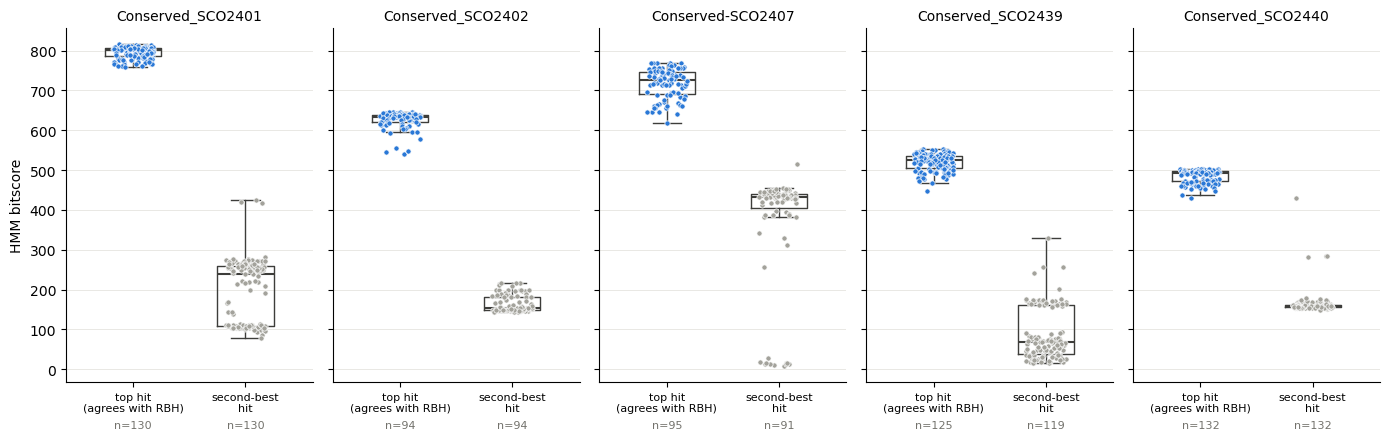

In [10]:
C_TOP = "#2a78d6"     # top HMM hit = RBH ortholog
C_SECOND = "#a3a29b"  # second-best HMM hit

genes = sorted(agreement_rbh_hmm_table.qseqid.unique())
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(genes), figsize=(2.8 * len(genes), 4.5), sharey=True)

for ax, gene in zip(axes, genes):
    groups = [
        ("top hit\n(agrees with RBH)", agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.qseqid == gene, "hmm_bitscore"], C_TOP),
        ("second-best\nhit", second_best_hits.loc[second_best_hits.qseqid == gene, "second_bitscore"], C_SECOND),
    ]
    for x, (label, values, color) in enumerate(groups):
        ax.boxplot(values, positions=[x], widths=0.5, showfliers=False,
                   medianprops={"color": "#3d3d3a", "linewidth": 1.5},
                   boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
        ax.scatter(x + rng.uniform(-0.18, 0.18, len(values)), values, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
        ax.text(x, -0.13, f"n={len(values)}", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=8, color="#73726c")
    ax.set_xticks([0, 1], [label for label, _, _ in groups], fontsize=8)
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.qseqid == gene, "model"].iloc[0], fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("HMM bitscore")
fig.tight_layout()
plt.show()

Check what is the second best hit in the SCO2440

In [14]:
second_best_hits.loc[second_best_hits.model == "Conserved_SCO2440"].sort_values("bitscore_gap", ascending=True).head(10)

,qseqid,genome,model,hmm_locus_tag,hmm_bitscore,second_locus_tag,second_hit,second_evalue,second_bitscore,second_is_rbh,bitscore_gap
561,SCO2440,Streptomyces_zaomyceticus,Conserved_SCO2440,OG567_RS34800,447.1,OG567_RS33900,Streptomyces_zaomyceticus|OG567_RS33900|IclR,9.100000e-130,430.5,True,16.6
544,SCO2440,Streptomyces_yatensis,Conserved_SCO2440,J8403_RS29415,489.5,J8403_RS35900,Streptomyces_yatensis|J8403_RS35900|IclR,1.300000e-84,282.6,False,206.9
531,SCO2440,Streptomyces_rapamycinicus_NRRL_5491,Conserved_SCO2440,LIV37_RS33575,492.2,LIV37_RS42690,Streptomyces_rapamycinicus_NRRL_5491|LIV37_RS4...,2.600000e-85,285.1,False,207.1
533,SCO2440,Streptomyces_iranensis,Conserved_SCO2440,RY074_RS33290,492.5,RY074_RS41405,Streptomyces_iranensis|RY074_RS41405|IclR,7.300000e-85,283.6,False,208.9
565,SCO2440,Peterkaempfera_sp._SMS_1(5)a,Conserved_SCO2440,AB0761_RS30795,430.1,AB0761_RS35005,Peterkaempfera_sp._SMS_1(5)a|AB0761_RS35005|IclR,2.000000e-46,157.2,False,272.9
540,SCO2440,Streptomyces_liangshanensis,Conserved_SCO2440,HA039_RS04620,451.6,HA039_RS31325,Streptomyces_liangshanensis|HA039_RS31325|IclR,6.800000e-51,171.7,False,279.9
564,SCO2440,Streptomyces_castrisilvae,Conserved_SCO2440,P8A18_RS29640,436.4,P8A18_RS22130,Streptomyces_castrisilvae|P8A18_RS22130|IclR,5.600000e-46,155.7,False,280.7
554,SCO2440,Streptomyces_bathyalis,Conserved_SCO2440,G4Z16_RS24380,468.3,G4Z16_RS22920,Streptomyces_bathyalis|G4Z16_RS22920|IclR,2.200000e-53,179.8,False,288.5
538,SCO2440,Streptomyces_niveus,Conserved_SCO2440,OG275_RS00925,459.3,OG275_RS02375,Streptomyces_niveus|OG275_RS02375|IclR,2.400000e-50,170.1,False,289.2
547,SCO2440,Streptomyces_scopuliridis,Conserved_SCO2440,OG949_RS05830,462.9,OG949_RS33175,Streptomyces_scopuliridis|OG949_RS33175|IclR,8.400000e-51,171.7,False,291.2


In [15]:
# lowest bitscore of the RBH-confirmed true hits per model
lowest_true_hit = (
    agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.groupby("model").hmm_bitscore.idxmin()]
    [["model", "qseqid", "genome", "hmm_locus_tag", "hmm_bitscore"]]
    .set_index("model")
)

# SCO2440: use the second S. zaomyceticus copy (OG567_RS33900, IclR), accepted as a true hit
zaomyceticus_iclr = hmm_hits[
    (hmm_hits.genome_set == "Streptomycetae")
    & (hmm_hits.genome == "Streptomyces_zaomyceticus")
    & (hmm_hits.locus_tag == "OG567_RS33900")
    & (hmm_hits.gene == "SCO2440")
].iloc[0]
lowest_true_hit.loc[zaomyceticus_iclr.model, ["genome", "hmm_locus_tag", "hmm_bitscore"]] = [
    zaomyceticus_iclr.genome, zaomyceticus_iclr.locus_tag, zaomyceticus_iclr.bitscore,
]
lowest_true_hit

,qseqid,genome,hmm_locus_tag,hmm_bitscore
model,,,,
Conserved-SCO2407,SCO2407,Streptomyces_bathyalis,G4Z16_RS02255,618.8
Conserved_SCO2401,SCO2401,Streptomyces_xiamenensis,SXIM_RS06610,760.0
Conserved_SCO2402,SCO2402,Streptomyces_xinghaiensis_S187,SXIN_RS22475,539.7
Conserved_SCO2439,SCO2439,Streptomyces_liangshanensis,HA039_RS04615,446.7
Conserved_SCO2440,SCO2440,Streptomyces_zaomyceticus,OG567_RS33900,430.5


In [16]:
# S. zaomyceticus SCO2440: the rank-2 hit (OG567_RS33900) is a true hit, so use its rank-3 hit as second-best
zaomyceticus_third = hmm_hits[
    (hmm_hits.genome_set == "Streptomycetae")
    & (hmm_hits.genome == "Streptomyces_zaomyceticus")
    & (hmm_hits.gene == "SCO2440")
    & (hmm_hits["rank"] == 3)
].rename(columns={"gene": "qseqid", "locus_tag": "second_locus_tag", "target": "second_hit",
                  "evalue": "second_evalue", "bitscore": "second_bitscore", "is_rbh": "second_is_rbh"})

non_ortholog_hits = pd.concat([
    second_best_hits[second_best_hits.second_locus_tag != "OG567_RS33900"],
    zaomyceticus_third[["qseqid", "genome", "model", "second_locus_tag", "second_hit",
                        "second_evalue", "second_bitscore", "second_is_rbh"]],
], ignore_index=True)

# highest bitscore of the second-best (non-ortholog) hits per model
highest_second_best = (
    non_ortholog_hits.loc[non_ortholog_hits.groupby("model").second_bitscore.idxmax()]
    [["model", "qseqid", "genome", "second_locus_tag", "second_bitscore"]]
    .set_index("model")
)
highest_second_best

,qseqid,genome,second_locus_tag,second_bitscore
model,,,,
Conserved-SCO2407,SCO2407,Streptomyces_boninensis,ACNNMR_RS12475,516.0
Conserved_SCO2401,SCO2401,Streptomyces_poriferorum,P8A21_RS06230,426.0
Conserved_SCO2402,SCO2402,Streptomyces_hygroscopicus_subsp._hygroscopicus,V8J11_RS38770,216.4
Conserved_SCO2439,SCO2439,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SRIM_RS07985,328.8
Conserved_SCO2440,SCO2440,Streptomyces_rapamycinicus_NRRL_5491,LIV37_RS42690,285.1


In [17]:
THRESHOLD_FRACTION = 0.2

thresholds = pd.DataFrame({
    "highest_second_best": highest_second_best.second_bitscore,
    "lowest_true_hit": lowest_true_hit.hmm_bitscore,
})
thresholds["gap"] = thresholds.lowest_true_hit - thresholds.highest_second_best
thresholds["threshold"] = thresholds.highest_second_best + THRESHOLD_FRACTION * thresholds.gap
thresholds.round(1)

,highest_second_best,lowest_true_hit,gap,threshold
model,,,,
Conserved-SCO2407,516.0,618.8,102.8,536.6
Conserved_SCO2401,426.0,760.0,334.0,492.8
Conserved_SCO2402,216.4,539.7,323.3,281.1
Conserved_SCO2439,328.8,446.7,117.9,352.4
Conserved_SCO2440,285.1,430.5,145.4,314.2


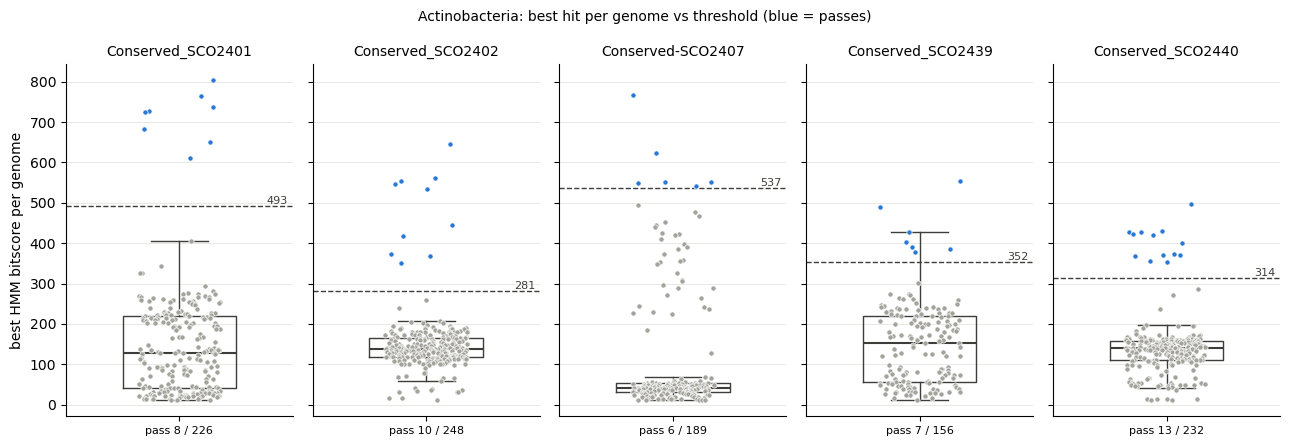

In [18]:
# best hit per (genome, model) in the Actinobacteria set, against the per-model threshold
actino_top = hmm_hits[(hmm_hits.genome_set == "Actinobacteria") & (hmm_hits["rank"] == 1)].copy()
actino_top["threshold"] = actino_top.model.map(thresholds.threshold)
actino_top = actino_top[actino_top.threshold.notna()]  # SCO2408 has no threshold
actino_top["passes"] = actino_top.bitscore >= actino_top.threshold

C_PASS = "#2a78d6"
C_FAIL = "#a3a29b"

models = sorted(thresholds.index, key=lambda m: m[-7:])  # by gene, not by the "-" / "_" in the name
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(models), figsize=(2.6 * len(models), 4.5), sharey=True)

for ax, model in zip(axes, models):
    sub = actino_top[actino_top.model == model]
    ax.boxplot(sub.bitscore, positions=[0], widths=0.5, showfliers=False,
               medianprops={"color": "#3d3d3a", "linewidth": 1.5},
               boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
    for passes, color in [(False, C_FAIL), (True, C_PASS)]:
        y = sub.loc[sub.passes == passes, "bitscore"]
        ax.scatter(rng.uniform(-0.18, 0.18, len(y)), y, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
    threshold = thresholds.loc[model, "threshold"]
    ax.axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.text(0.48, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    ax.set_xticks([0], [f"pass {sub.passes.sum()} / {len(sub)}"], fontsize=8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(model, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("best HMM bitscore per genome")
fig.suptitle("Actinobacteria: best hit per genome vs threshold (blue = passes)", fontsize=10)
fig.tight_layout()
plt.show()